PROCESO OPTIMIZADO CON SVR NO LINEAL (KERNEL RBF)

Cargando datos de entrenamiento desde: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\3_95_5\3_meteo_epi_2021-2026_1_rezagos_meteo_train_95_5.xlsx
Datos de entrenamiento: 256 muestras, 159 características
Iniciando ingeniería de atributos optimizada...
Escalando características (requerido para SVR)...
Características después de ingeniería: 182

BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS (SVR)

Probando 10 características...
  CV MAE: 9.7659
  CV Peak MAE: 45.6983

Probando 15 características...
  CV MAE: 8.9622
  CV Peak MAE: 43.0952

Probando 20 características...
  CV MAE: 8.7459
  CV Peak MAE: 43.8267

Probando 25 características...
  CV MAE: 8.9931
  CV Peak MAE: 44.0976

Probando 30 características...
  CV MAE: 8.9697
  CV Peak MAE: 43.8330

Probando 35 características...
  CV MAE: 9.0357
  CV Peak MAE: 44.1748

✅ NÚMERO ÓPTIMO DE CARACTERÍSTICAS: 15
   Weighted Score: 29.4420

AJUSTE DE HI

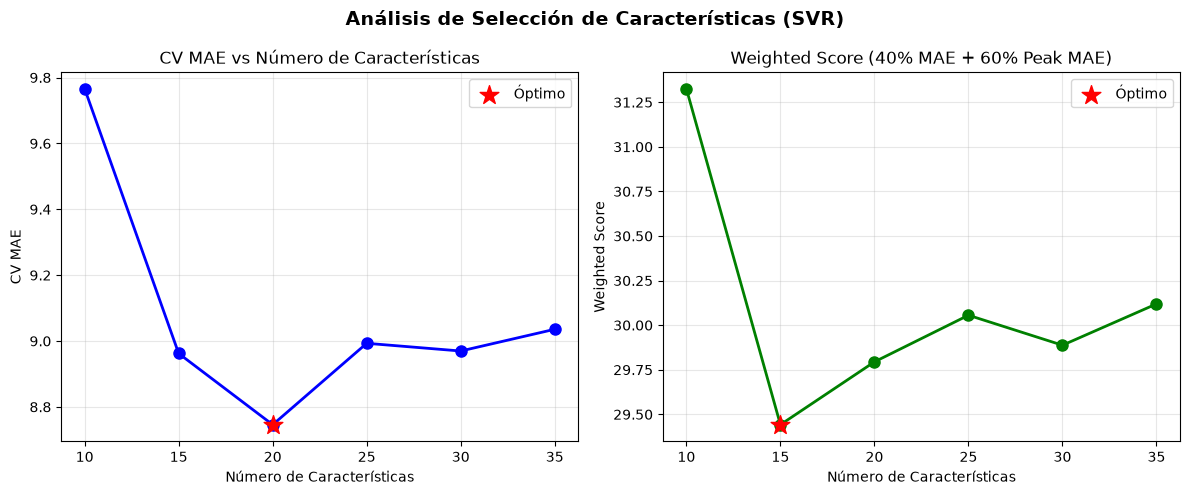

✅ Análisis de picos guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\3_95_5\analisis_picos_svr_20260909_091826.png


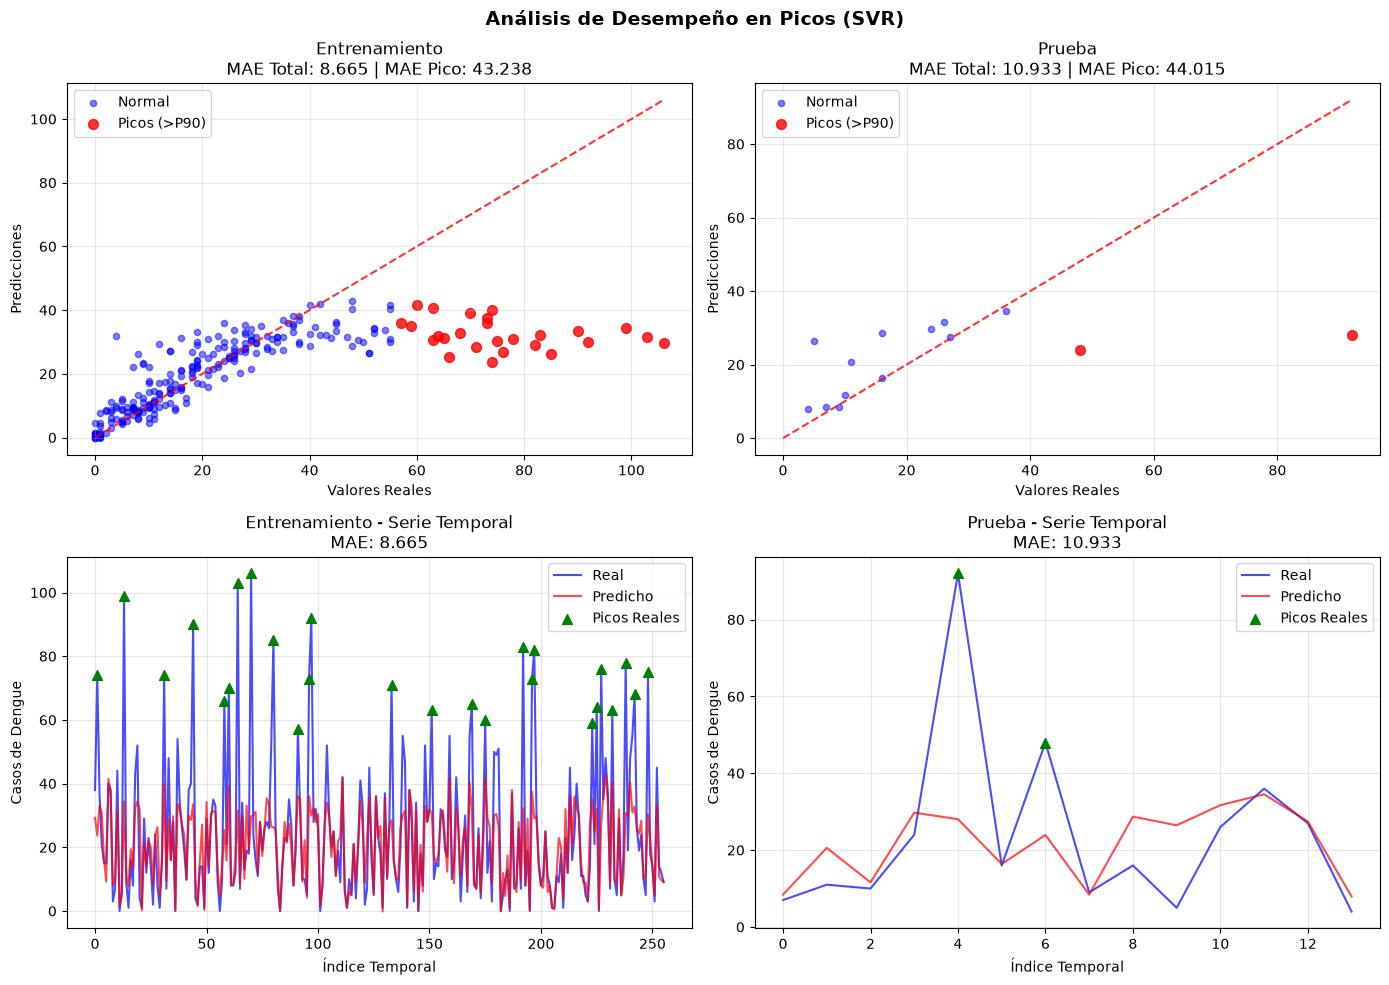

✅ Comparación guardada en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\3_95_5\comparacion_desempeno_svr_20260909_091826.png


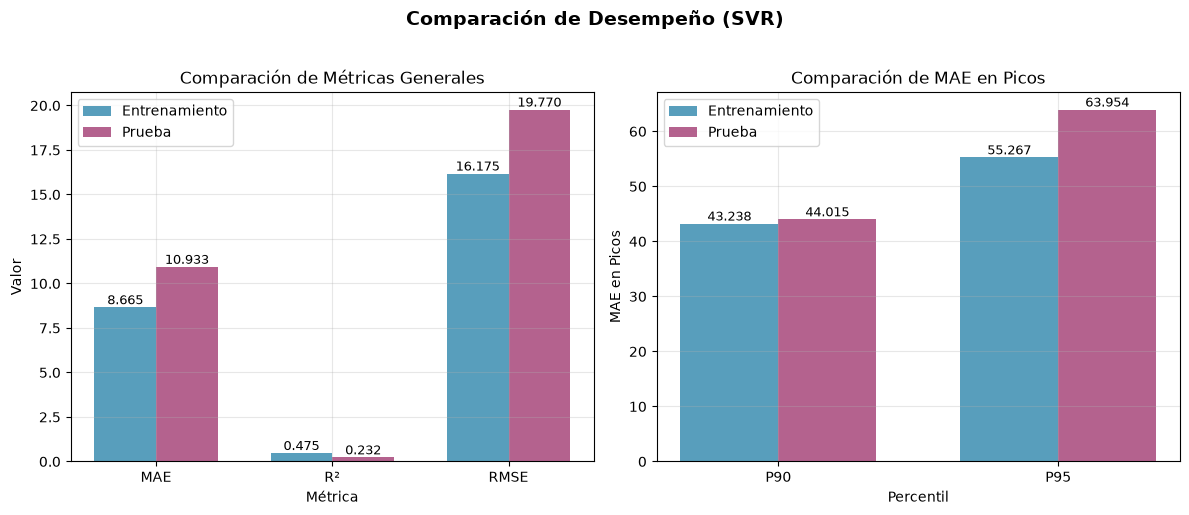


PROCESO COMPLETADO EXITOSAMENTE
Resultados: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\3_95_5\resultados_svr_20260909_091826.xlsx
Modelo guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\3_95_5\modelo_svr_optimizada


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from scipy.stats import loguniform
import warnings
import os
from datetime import datetime
import json
import pickle
import time

warnings.filterwarnings('ignore')

class DengueFeatureEngineeringSVR:
    def __init__(self, n_features_to_select=25):
        """
        Clase optimizada para ingeniería de atributos con enfoque en picos
        usando Support Vector Regression (SVR) con Kernel no lineal (RBF)
        """
        self.n_features_to_select = n_features_to_select
        self.scaler = StandardScaler()
        self.selected_features = None
        self.feature_names = None
        self.svr_model = None
        self.numeric_columns = None
        self.best_params = None
        self.X_augmented_columns = None
        self.best_metrics = None
        self.feature_selection_results = None
        self.cv_scores = None
        
    def create_interaction_features(self, X):
        """Crea características de interacción"""
        interaction_data = pd.DataFrame(index=X.index)
        
        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
            ('prec', 'dias_lluvia', 'prec_dias_lluvia'),
        ]
        
        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]
        
        return interaction_data
    
    def create_polynomial_features(self, X):
        """Crea características polinomiales"""
        important_vars = ['temp', 'hum_rel', 'prec', 'dias_lluvia']
        poly_features = pd.DataFrame(index=X.index)
        
        for var in important_vars:
            if var in X.columns:
                poly_features[f'{var}_squared'] = X[var] ** 2
        
        return poly_features
    
    def create_lag_aggregates(self, X):
        """Crea agregados de rezagos"""
        lag_aggs = pd.DataFrame(index=X.index)
        
        # Agregados para variables climáticas
        for base_var in ['temp', 'hum_rel', 'prec']:
            lag_cols = [col for col in X.columns if col.startswith(f'{base_var}_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[f'{base_var}_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[f'{base_var}_lag_std'] = lag_data.std(axis=1)
                lag_aggs[f'{base_var}_lag_max'] = lag_data.max(axis=1)
        
        # Agregados para casos de dengue
        dengue_lag_cols = [col for col in X.columns if col.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            dengue_lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = dengue_lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = dengue_lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = dengue_lag_data.sum(axis=1)
            lag_aggs['dengue_lag_max'] = dengue_lag_data.max(axis=1)
            
            if dengue_lag_data.shape[1] >= 4:
                lag_aggs['dengue_lag_trend'] = dengue_lag_data.iloc[:, -1] - dengue_lag_data.iloc[:, 0]
        
        return lag_aggs
    
    def create_rolling_features(self, X):
        """Crea características de tendencia temporal"""
        rolling_features = pd.DataFrame(index=X.index)
        
        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)
        
        dengue_lags = [col for col in X.columns if col.startswith('casos_dengue_lag_')]
        dengue_lags_sorted = sorted(dengue_lags, key=lambda x: int(x.split('_')[-1]))
        
        if len(dengue_lags_sorted) >= 4:
            rolling_features['dengue_trend_4w'] = X[dengue_lags_sorted[0]] - X[dengue_lags_sorted[3]]
            if len(dengue_lags_sorted) >= 8:
                rolling_features['dengue_trend_8w'] = X[dengue_lags_sorted[0]] - X[dengue_lags_sorted[7]]
        
        return rolling_features
    
    def create_peak_indicators(self, X):
        """Crea indicadores de condiciones propicias para picos"""
        peak_features = pd.DataFrame(index=X.index)
        
        if 'temp' in X.columns and 'hum_rel' in X.columns:
            temp_high = X['temp'] > X['temp'].quantile(0.75)
            hum_high = X['hum_rel'] > X['hum_rel'].quantile(0.75)
            peak_features['temp_hum_high'] = (temp_high & hum_high).astype(int)
        
        if 'dias_lluvia' in X.columns:
            peak_features['rain_recent'] = (X['dias_lluvia'] > X['dias_lluvia'].quantile(0.75)).astype(int)
        
        dengue_lags = [col for col in X.columns if col.startswith('casos_dengue_lag_')]
        if len(dengue_lags) >= 2:
            dengue_lags_sorted = sorted(dengue_lags, key=lambda x: int(x.split('_')[-1]))
            peak_features['dengue_recent_high'] = (X[dengue_lags_sorted[0]] > X[dengue_lags_sorted[0]].quantile(0.75)).astype(int)
        
        return peak_features
    
    def get_numeric_columns(self, X):
        """Identifica columnas numéricas"""
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []
        
        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)
        
        return numeric_cols
    
    def augment_features(self, X):
        """Aplica ingeniería de atributos"""
        numeric_cols = self.get_numeric_columns(X)
        X_numeric = X[numeric_cols]
        
        features_list = [X_numeric]
        
        interaction_features = self.create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)
        
        poly_features = self.create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)
        
        lag_aggs = self.create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)
        
        rolling_features = self.create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)
        
        peak_features = self.create_peak_indicators(X_numeric)
        if not peak_features.empty:
            features_list.append(peak_features)
        
        X_augmented = pd.concat(features_list, axis=1)
        
        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.median())
        
        return X_augmented, X_numeric
    
    def fit_transform(self, X, y=None):
        """Aplica transformaciones"""
        print("Iniciando ingeniería de atributos optimizada...")
        
        X_augmented, X_numeric = self.augment_features(X)
        
        self.numeric_columns = X_numeric.columns.tolist()
        self.X_augmented_columns = X_augmented.columns.tolist()
        self.feature_names = X_augmented.columns.tolist()
        
        print("Escalando características (requerido para SVR)...")
        X_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        print(f"Características después de ingeniería: {X_augmented.shape[1]}")
        
        return X_scaled, X_augmented
    
    def transform_features(self, X):
        """Aplica transformación a nuevos datos"""
        X_augmented, X_numeric = self.augment_features(X)
        
        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0
        
        X_augmented = X_augmented[self.X_augmented_columns]
        
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        return X_scaled
    
    def select_features_fast(self, X_scaled, y):
        """Selección rápida de características usando Mutual Information"""
        print("\nSeleccionando características relevantes...")
        
        n_features = min(self.n_features_to_select, X_scaled.shape[1])
        
        try:
            selector = SelectKBest(mutual_info_regression, k=n_features)
            selector.fit(X_scaled, y)
            selected_features = X_scaled.columns[selector.get_support()].tolist()
        except:
            selected_features = X_scaled.columns[:n_features].tolist()
        
        print(f"  Seleccionadas {len(selected_features)} características")
        print(f"  Top 5: {selected_features[:5]}")
        
        self.selected_features = selected_features
        return selected_features
    
    def find_optimal_features(self, X_scaled, y, feature_range=None):
        """
        Encuentra el número óptimo de características evaluadas mediante SVR
        """
        if feature_range is None:
            feature_range = [10, 15, 20, 25, 30]
        
        print("\n" + "="*60)
        print("BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS (SVR)")
        print("="*60)
        
        # Estimación de importancia por permutación con SVR no lineal
        svr_base = SVR(kernel='rbf', C=10.0, epsilon=0.1)
        svr_base.fit(X_scaled, y)
        
        perm_importance = permutation_importance(
            svr_base, X_scaled, y, n_repeats=5, random_state=42, scoring='neg_mean_absolute_error'
        )
        sorted_indices = np.argsort(perm_importance.importances_mean)[::-1]
        
        results = []
        best_cv_mae = float('inf')
        best_n_features = None
        best_features = None
        
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        
        for n_features in feature_range:
            if n_features > X_scaled.shape[1]:
                continue
                
            print(f"\nProbando {n_features} características...")
            
            selected_indices = sorted_indices[:n_features]
            selected_cols = X_scaled.columns[selected_indices].tolist()
            
            cv_maes = []
            cv_peak_maes = []
            
            for train_idx, val_idx in cv.split(X_scaled):
                X_tr = X_scaled.iloc[train_idx][selected_cols]
                X_v = X_scaled.iloc[val_idx][selected_cols]
                y_tr = y.iloc[train_idx]
                y_v = y.iloc[val_idx]
                
                svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.1)
                svr_model.fit(X_tr, y_tr)
                y_pred = svr_model.predict(X_v)
                
                cv_maes.append(mean_absolute_error(y_v, y_pred))
                
                peak_threshold_v = np.percentile(y_v, 90)
                peak_mask_v = y_v > peak_threshold_v
                if np.sum(peak_mask_v) > 0:
                    cv_peak_maes.append(mean_absolute_error(y_v[peak_mask_v], y_pred[peak_mask_v]))
                else:
                    cv_peak_maes.append(float('inf'))
            
            mean_cv_mae = np.mean(cv_maes)
            mean_cv_peak_mae = np.mean([m for m in cv_peak_maes if m != float('inf')])
            
            weighted_score = 0.4 * mean_cv_mae + 0.6 * mean_cv_peak_mae if mean_cv_peak_mae != float('inf') else mean_cv_mae
            
            print(f"  CV MAE: {mean_cv_mae:.4f}")
            print(f"  CV Peak MAE: {mean_cv_peak_mae:.4f}")
            
            results.append({
                'n_features': n_features,
                'cv_mae': mean_cv_mae,
                'cv_peak_mae': mean_cv_peak_mae,
                'weighted_score': weighted_score
            })
            
            if weighted_score < best_cv_mae:
                best_cv_mae = weighted_score
                best_n_features = n_features
                best_features = selected_cols
        
        print("\n" + "="*60)
        print(f"✅ NÚMERO ÓPTIMO DE CARACTERÍSTICAS: {best_n_features}")
        print(f"   Weighted Score: {best_cv_mae:.4f}")
        print("="*60)
        
        self.selected_features = best_features
        self.n_features_to_select = best_n_features
        self.feature_selection_results = pd.DataFrame(results)
        
        return best_n_features, results, {'cv_mae': best_cv_mae}
    
    def transform_with_selected_features(self, X_scaled):
        """Transforma usando las características seleccionadas"""
        if self.selected_features is None or len(self.selected_features) == 0:
            n = min(25, X_scaled.shape[1])
            self.selected_features = X_scaled.columns[:n].tolist()
        return X_scaled[self.selected_features]
    
    def tune_hyperparameters_fast(self, X_train, y_train, X_test, y_test):
        """
        Ajuste rápido de hiperparámetros para SVR (Kernel RBF)
        """
        print("\n" + "="*60)
        print("AJUSTE DE HIPERPARÁMETROS DE SVR (KERNEL RBF)")
        print("="*60)
        
        param_grid = {
            'C': loguniform(1e-1, 1e3),
            'gamma': loguniform(1e-4, 1e1),
            'epsilon': loguniform(1e-3, 1e1),
            'kernel': ['rbf']
        }
        
        svr_model = SVR()
        
        random_search = RandomizedSearchCV(
            estimator=svr_model,
            param_distributions=param_grid,
            n_iter=15,
            cv=3,
            scoring='neg_mean_absolute_error',
            n_jobs=-1,
            random_state=42,
            verbose=1
        )
        
        random_search.fit(X_train, y_train)
        
        best_params = random_search.best_params_
        best_model = random_search.best_estimator_
        
        print("\n" + "="*60)
        print("✅ MEJORES HIPERPARÁMETROS ENCONTRADOS:")
        print("="*60)
        for key, value in best_params.items():
            print(f"  {key}: {value}")
        
        # Evaluación
        y_pred_train = best_model.predict(X_train)
        y_pred_test = best_model.predict(X_test)
        
        mae_train = mean_absolute_error(y_train, y_pred_train)
        r2_train = r2_score(y_train, y_pred_train)
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)
        
        threshold = np.percentile(y_train, 90)
        peak_mask_train = y_train > threshold
        peak_mae_train = mean_absolute_error(y_train[peak_mask_train], y_pred_train[peak_mask_train]) if np.sum(peak_mask_train) > 0 else np.nan
        
        threshold_test = np.percentile(y_test, 90)
        peak_mask_test = y_test > threshold_test
        peak_mae_test = mean_absolute_error(y_test[peak_mask_test], y_pred_test[peak_mask_test]) if np.sum(peak_mask_test) > 0 else np.nan
        
        print(f"\nMAE Train: {mae_train:.4f}")
        print(f"MAE Test: {mae_test:.4f}")
        print(f"R² Train: {r2_train:.4f}")
        print(f"R² Test: {r2_test:.4f}")
        print(f"Peak MAE Train: {peak_mae_train:.4f}")
        print(f"Peak MAE Test: {peak_mae_test:.4f}")
        
        self.best_params = best_params
        self.svr_model = best_model
        self.train_val_metrics = {
            'mae_train': mae_train,
            'r2_train': r2_train,
            'mae_test': mae_test,
            'r2_test': r2_test,
            'peak_mae_train': peak_mae_train,
            'peak_mae_test': peak_mae_test,
            'overfit_gap': mae_test - mae_train,
            'best_params': best_params
        }
        
        return best_params, best_model
    
    def evaluate_model_detailed(self, X_test, y_test, dataset_name="Test"):
        """Evalúa el modelo SVR con métricas detalladas"""
        y_pred = self.svr_model.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        peak_metrics = {}
        for p in [90, 95, 97.5]:
            try:
                threshold = np.percentile(y_test, p)
                peak_mask = y_test > threshold
                if np.sum(peak_mask) > 0:
                    peak_mae = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])
                    peak_metrics[f'P{p}_MAE'] = peak_mae
                    peak_metrics[f'P{p}_Threshold'] = threshold
                    peak_metrics[f'P{p}_Count'] = np.sum(peak_mask)
            except:
                pass
        
        print(f"\n{'='*60}")
        print(f"MÉTRICAS DETALLADAS (SVR) - {dataset_name}")
        print(f"{'='*60}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        if peak_metrics:
            print(f"\nMétricas para picos:")
            for key, value in peak_metrics.items():
                if isinstance(value, float):
                    print(f"  {key}: {value:.4f}")
                else:
                    print(f"  {key}: {value}")
        
        return {
            'MAE': mae,
            'R2': r2,
            'RMSE': rmse,
            'peak_metrics': peak_metrics,
            'predictions': y_pred,
            'actual': y_test.values if hasattr(y_test, 'values') else y_test
        }


# ==========================================
# FUNCIONES DE GRAFICACIÓN
# ==========================================

def plot_feature_selection_results(results, best_metrics, save_path=None):
    """Grafica los resultados de la búsqueda de características"""
    if results is None or len(results) == 0:
        print("No hay resultados para graficar")
        return None
    
    df = pd.DataFrame(results)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1 = axes[0]
    ax1.plot(df['n_features'], df['cv_mae'], 'bo-', linewidth=2, markersize=8)
    best_idx = df['cv_mae'].idxmin()
    ax1.scatter(df.loc[best_idx, 'n_features'], df.loc[best_idx, 'cv_mae'], 
               color='red', s=200, marker='*', zorder=5, label='Óptimo')
    ax1.set_xlabel('Número de Características')
    ax1.set_ylabel('CV MAE')
    ax1.set_title('CV MAE vs Número de Características')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    if 'weighted_score' in df.columns:
        ax2.plot(df['n_features'], df['weighted_score'], 'go-', linewidth=2, markersize=8)
        best_score_idx = df['weighted_score'].idxmin()
        ax2.scatter(df.loc[best_score_idx, 'n_features'], df.loc[best_score_idx, 'weighted_score'], 
                   color='red', s=200, marker='*', zorder=5, label='Óptimo')
        ax2.set_xlabel('Número de Características')
        ax2.set_ylabel('Weighted Score')
        ax2.set_title('Weighted Score (40% MAE + 60% Peak MAE)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Análisis de Selección de Características (SVR)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de selección guardado en: {save_path}")
    plt.show()
    return fig


def plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=None):
    """Analiza y grafica el desempeño en picos"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    try:
        ax1 = axes[0, 0]
        train_actual = train_metrics['actual']
        train_pred = train_metrics['predictions']
        threshold_train = np.percentile(train_actual, 90)
        peak_mask_train = train_actual > threshold_train
        
        ax1.scatter(train_actual[~peak_mask_train], train_pred[~peak_mask_train], 
                    alpha=0.5, color='blue', label='Normal', s=20)
        ax1.scatter(train_actual[peak_mask_train], train_pred[peak_mask_train], 
                    alpha=0.8, color='red', label='Picos (>P90)', s=50)
        
        max_val = max(train_actual.max(), train_pred.max())
        ax1.plot([0, max_val], [0, max_val], 'r--', alpha=0.8, linewidth=1.5)
        ax1.set_xlabel('Valores Reales')
        ax1.set_ylabel('Predicciones')
        peak_mae_train = train_metrics['peak_metrics'].get('P90_MAE', 0)
        ax1.set_title(f'Entrenamiento\nMAE Total: {train_metrics["MAE"]:.3f} | MAE Pico: {peak_mae_train:.3f}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2 = axes[0, 1]
        test_actual = test_metrics['actual']
        test_pred = test_metrics['predictions']
        threshold_test = np.percentile(test_actual, 90)
        peak_mask_test = test_actual > threshold_test
        
        ax2.scatter(test_actual[~peak_mask_test], test_pred[~peak_mask_test], 
                    alpha=0.5, color='blue', label='Normal', s=20)
        ax2.scatter(test_actual[peak_mask_test], test_pred[peak_mask_test], 
                    alpha=0.8, color='red', label='Picos (>P90)', s=50)
        
        max_val = max(test_actual.max(), test_pred.max())
        ax2.plot([0, max_val], [0, max_val], 'r--', alpha=0.8, linewidth=1.5)
        ax2.set_xlabel('Valores Reales')
        ax2.set_ylabel('Predicciones')
        peak_mae_test = test_metrics['peak_metrics'].get('P90_MAE', 0)
        ax2.set_title(f'Prueba\nMAE Total: {test_metrics["MAE"]:.3f} | MAE Pico: {peak_mae_test:.3f}')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        ax3 = axes[1, 0]
        indices_train = np.arange(len(train_actual))
        ax3.plot(indices_train, train_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
        ax3.plot(indices_train, train_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
        peak_indices_train = np.where(peak_mask_train)[0]
        ax3.scatter(peak_indices_train, train_actual[peak_mask_train], 
                   color='green', s=50, marker='^', label='Picos Reales', zorder=5)
        ax3.set_xlabel('Índice Temporal')
        ax3.set_ylabel('Casos de Dengue')
        ax3.set_title(f'Entrenamiento - Serie Temporal\nMAE: {train_metrics["MAE"]:.3f}')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        ax4 = axes[1, 1]
        indices_test = np.arange(len(test_actual))
        ax4.plot(indices_test, test_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
        ax4.plot(indices_test, test_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
        peak_indices_test = np.where(peak_mask_test)[0]
        ax4.scatter(peak_indices_test, test_actual[peak_mask_test], 
                   color='green', s=50, marker='^', label='Picos Reales', zorder=5)
        ax4.set_xlabel('Índice Temporal')
        ax4.set_ylabel('Casos de Dengue')
        ax4.set_title(f'Prueba - Serie Temporal\nMAE: {test_metrics["MAE"]:.3f}')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
    except Exception as e:
        print(f"⚠️ Error en gráfico de picos: {e}")
    
    plt.suptitle('Análisis de Desempeño en Picos (SVR)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Análisis de picos guardado en: {save_path}")
    
    plt.show()
    return fig


def plot_performance_comparison(train_metrics, test_metrics, save_path=None):
    """Grafica comparación de desempeño"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    try:
        ax1 = axes[0]
        metrics = ['MAE', 'R²', 'RMSE']
        train_values = [train_metrics['MAE'], train_metrics['R2'], train_metrics['RMSE']]
        test_values = [test_metrics['MAE'], test_metrics['R2'], test_metrics['RMSE']]
        
        x = np.arange(len(metrics))
        width = 0.35
        
        bars1 = ax1.bar(x - width/2, train_values, width, label='Entrenamiento', color='#2E86AB', alpha=0.8)
        bars2 = ax1.bar(x + width/2, test_values, width, label='Prueba', color='#A23B72', alpha=0.8)
        
        ax1.set_xlabel('Métrica')
        ax1.set_ylabel('Valor')
        ax1.set_title('Comparación de Métricas Generales')
        ax1.set_xticks(x)
        ax1.set_xticklabels(metrics)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        for bar in bars2:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
        ax2 = axes[1]
        peak_percentiles = [90, 95]
        train_peak_mae = [train_metrics['peak_metrics'].get(f'P{p}_MAE', 0) for p in peak_percentiles]
        test_peak_mae = [test_metrics['peak_metrics'].get(f'P{p}_MAE', 0) for p in peak_percentiles]
        
        x = np.arange(len(peak_percentiles))
        width = 0.35
        
        bars1 = ax2.bar(x - width/2, train_peak_mae, width, label='Entrenamiento', color='#2E86AB', alpha=0.8)
        bars2 = ax2.bar(x + width/2, test_peak_mae, width, label='Prueba', color='#A23B72', alpha=0.8)
        
        ax2.set_xlabel('Percentil')
        ax2.set_ylabel('MAE en Picos')
        ax2.set_title('Comparación de MAE en Picos')
        ax2.set_xticks(x)
        ax2.set_xticklabels([f'P{p}' for p in peak_percentiles])
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        for bar in bars1:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        for bar in bars2:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
    except Exception as e:
        print(f"⚠️ Error en gráfico de comparación: {e}")
    
    plt.suptitle('Comparación de Desempeño (SVR)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Comparación guardada en: {save_path}")
    
    plt.show()
    return fig


def save_detailed_results(results, feature_results, best_metrics, selected_features, 
                          best_params, train_val_metrics, filepath):
    """Guarda resultados detallados en Excel"""
    try:
        with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
            df_metrics = pd.DataFrame({
                'Dataset': ['Train', 'Test'],
                'MAE': [results['train']['MAE'], results['test']['MAE']],
                'R2': [results['train']['R2'], results['test']['R2']],
                'RMSE': [results['train']['RMSE'], results['test']['RMSE']]
            })
            df_metrics.to_excel(writer, sheet_name='Métricas', index=False)
            
            peak_data = []
            for dataset in ['train', 'test']:
                for p in [90, 95, 97.5]:
                    key = f'P{p}_MAE'
                    if key in results[dataset]['peak_metrics']:
                        val = results[dataset]['peak_metrics'][key]
                        if not np.isnan(val) and not np.isinf(val):
                            peak_data.append({
                                'Dataset': dataset.capitalize(),
                                'Percentil': p,
                                'MAE_Pico': val,
                                'Threshold': results[dataset]['peak_metrics'].get(f'P{p}_Threshold', np.nan),
                                'N_Picos': results[dataset]['peak_metrics'].get(f'P{p}_Count', 0)
                            })
            
            if peak_data:
                df_peak = pd.DataFrame(peak_data)
                df_peak.to_excel(writer, sheet_name='Métricas_Picos', index=False)
            
            if selected_features:
                df_features = pd.DataFrame({
                    'Feature': selected_features,
                    'Index': range(1, len(selected_features) + 1)
                })
                df_features.to_excel(writer, sheet_name='Características_Seleccionadas', index=False)
            
            if best_params:
                df_params = pd.DataFrame({
                    'Parámetro': list(best_params.keys()),
                    'Valor': [str(v) for v in best_params.values()]
                })
                df_params.to_excel(writer, sheet_name='Mejores_Hiperparámetros', index=False)
            
            if train_val_metrics:
                df_tuning = pd.DataFrame({
                    'Métrica': ['MAE Train', 'MAE Test', 'R² Train', 'R² Test', 'Peak MAE Train', 'Peak MAE Test', 'Brecha Sobreajuste'],
                    'Valor': [
                        train_val_metrics.get('mae_train', np.nan),
                        train_val_metrics.get('mae_test', np.nan),
                        train_val_metrics.get('r2_train', np.nan),
                        train_val_metrics.get('r2_test', np.nan),
                        train_val_metrics.get('peak_mae_train', np.nan),
                        train_val_metrics.get('peak_mae_test', np.nan),
                        train_val_metrics.get('overfit_gap', np.nan)
                    ]
                })
                df_tuning.to_excel(writer, sheet_name='Validación', index=False)
            
            if feature_results:
                df_feature_search = pd.DataFrame(feature_results)
                df_feature_search.to_excel(writer, sheet_name='Búsqueda_Features', index=False)
            
            train_actual = np.nan_to_num(np.array(results['train']['actual']), nan=0.0)
            train_pred = np.nan_to_num(np.array(results['train']['predictions']), nan=0.0)
            test_actual = np.nan_to_num(np.array(results['test']['actual']), nan=0.0)
            test_pred = np.nan_to_num(np.array(results['test']['predictions']), nan=0.0)
            
            max_len = max(len(train_actual), len(test_actual))
            
            df_predictions = pd.DataFrame({
                'Train_Actual': np.pad(train_actual, (0, max_len - len(train_actual)), constant_values=np.nan),
                'Train_Predicted': np.pad(train_pred, (0, max_len - len(train_pred)), constant_values=np.nan),
                'Test_Actual': np.pad(test_actual, (0, max_len - len(test_actual)), constant_values=np.nan),
                'Test_Predicted': np.pad(test_pred, (0, max_len - len(test_pred)), constant_values=np.nan)
            })
            df_predictions.to_excel(writer, sheet_name='Predicciones', index=False)
        
        print(f"✅ Resultados detallados guardados en: {filepath}")
    except Exception as e:
        print(f"⚠️ Error al guardar en Excel: {e}")


# ===================== EJECUCIÓN PRINCIPAL =====================

if __name__ == "__main__":
    print("="*60)
    print("PROCESO OPTIMIZADO CON SVR NO LINEAL (KERNEL RBF)")
    print("="*60)
    
    base_path = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\3_95_5"
    output_dir = base_path
    
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    train_path = os.path.join(base_path, "3_meteo_epi_2021-2026_1_rezagos_meteo_train_95_5.xlsx")
    print(f"\nCargando datos de entrenamiento desde: {train_path}")
    train_data = pd.read_excel(train_path)
    
    X_train = train_data.drop('casos_dengue', axis=1)
    y_train = train_data['casos_dengue']
    
    print(f"Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características")
    
    engine = DengueFeatureEngineeringSVR(n_features_to_select=25)
    X_scaled, X_augmented = engine.fit_transform(X_train, y_train)
    
    X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(
        X_scaled, y_train, test_size=0.2, random_state=42
    )
    
    feature_range = [10, 15, 20, 25, 30, 35]
    best_n_features, feature_results, best_metrics = engine.find_optimal_features(
        X_scaled, y_train, feature_range
    )
    
    X_train_selected = engine.transform_with_selected_features(X_train_tune)
    X_test_selected = engine.transform_with_selected_features(X_test_tune)
    
    best_params, model = engine.tune_hyperparameters_fast(
        X_train_selected, y_train_tune, X_test_selected, y_test_tune
    )
    
    print("\n" + "="*60)
    print("EVALUANDO MODELO SVR EN DATOS DE ENTRENAMIENTO")
    print("="*60)
    X_train_full_selected = engine.transform_with_selected_features(X_scaled)
    train_metrics = engine.evaluate_model_detailed(X_train_full_selected, y_train, "Train")
    
    test_path = os.path.join(base_path, "3_meteo_epi_2021-2026_1_rezagos_meteo_test_95_5.xlsx")
    print(f"\nCargando datos de prueba desde: {test_path}")
    test_data = pd.read_excel(test_path)
    
    X_test = test_data.drop('casos_dengue', axis=1)
    y_test = test_data['casos_dengue']
    
    print(f"Datos de prueba: {X_test.shape[0]} muestras, {X_test.shape[1]} características")
    
    X_test_scaled = engine.transform_features(X_test)
    X_test_selected_final = engine.transform_with_selected_features(X_test_scaled)
    
    print("\n" + "="*60)
    print("EVALUANDO MODELO SVR EN DATOS DE PRUEBA")
    print("="*60)
    test_metrics = engine.evaluate_model_detailed(X_test_selected_final, y_test, "Test")
    
    print("\n" + "="*60)
    print("RESUMEN FINAL DE DESEMPEÑO")
    print("="*60)
    print(f"Características seleccionadas: {len(engine.selected_features)}")
    print(f"\nTrain - MAE: {train_metrics['MAE']:.4f}, R²: {train_metrics['R2']:.4f}")
    print(f"Test  - MAE: {test_metrics['MAE']:.4f}, R²: {test_metrics['R2']:.4f}")
    print(f"\nMAE en picos (>P90):")
    print(f"  Train: {train_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    print(f"  Test:  {test_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    
    overfit_gap = test_metrics['MAE'] - train_metrics['MAE']
    print(f"\nBrecha de sobreajuste: {overfit_gap:.4f}")
    
    results = {'train': train_metrics, 'test': test_metrics}
    
    excel_output = os.path.join(output_dir, f"resultados_svr_{timestamp}.xlsx")
    save_detailed_results(
        results, feature_results, best_metrics,
        engine.selected_features,
        best_params, engine.train_val_metrics, excel_output
    )
    
    feature_plot = os.path.join(output_dir, f"seleccion_features_svr_{timestamp}.png")
    plot_feature_selection_results(feature_results, best_metrics, save_path=feature_plot)
    
    peak_plot = os.path.join(output_dir, f"analisis_picos_svr_{timestamp}.png")
    plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=peak_plot)
    
    comparison_plot = os.path.join(output_dir, f"comparacion_desempeno_svr_{timestamp}.png")
    plot_performance_comparison(train_metrics, test_metrics, save_path=comparison_plot)
    
    model_dir = os.path.join(output_dir, "modelo_svr_optimizada")
    os.makedirs(model_dir, exist_ok=True)
    
    with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(engine.scaler, f)
    
    with open(os.path.join(model_dir, 'svr_model.pkl'), 'wb') as f:
        pickle.dump(engine.svr_model, f)
    
    config = {
        'selected_features': engine.selected_features,
        'X_augmented_columns': engine.X_augmented_columns,
        'best_params': {k: str(v) for k, v in best_params.items()},
        'train_mae': train_metrics['MAE'],
        'test_mae': test_metrics['MAE'],
        'train_r2': train_metrics['R2'],
        'test_r2': test_metrics['R2'],
        'train_peak_mae': train_metrics['peak_metrics'].get('P90_MAE', 0),
        'test_peak_mae': test_metrics['peak_metrics'].get('P90_MAE', 0),
        'overfit_gap': overfit_gap
    }
    
    with open(os.path.join(model_dir, 'model_config.json'), 'w') as f:
        json.dump(config, f, indent=4)
    
    print("\n" + "="*60)
    print("PROCESO COMPLETADO EXITOSAMENTE")
    print("="*60)
    print(f"Resultados: {excel_output}")
    print(f"Modelo guardado en: {model_dir}")